In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df=pd.read_csv("/Users/muritalaqudusajibola/Desktop/FRAUD DETECTION/data/raw/nova_pay_combined.csv")
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


EXPLORATORTY DATA ANALYSIS

In [3]:
# check the shape of the dataset
df.shape

(11400, 26)

OBSERVATION 

We have 11,400 rows and 26 Columns

In [4]:
# Checking the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [5]:
# Checking for missing values in the dataset
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [6]:
# Checking for missing values 
# The following are the columns with missing values 
cols_with_missing_values = df.columns[df.isnull().any()]
df[cols_with_missing_values].isnull().sum()

timestamp              29
amount_usd            305
fee                   295
ip_address            305
ip_country            301
kyc_tier              300
device_trust_score    295
dtype: int64

In [7]:
# Checking for duplicate values
df.duplicated().sum()

200

We have 200 rows of duplicated values we need to drop it

In [8]:
# Drop duplicate values
df.drop_duplicates(inplace=True)

In [9]:
# Checking for duplicate values again after dropping duplicates
df.duplicated().sum()

0

Duplicated values have been dropped 

In [10]:
# checking the distribution of the target variable
#0 represents non-fraudulent transactions, while 1 represents fraudulent transactions.
df['is_fraud'].value_counts()

is_fraud
0    10205
1      995
Name: count, dtype: int64

We have many cases of legit transactions compared to fraud transactions. We need to handle class imbalance bcos if we build a predictive model with this data without handling class imbalance our model will be biased to the majority class

0 10205   ---- represents legit transactions. majority class

1  995  ---- represents fraud transactions minority class


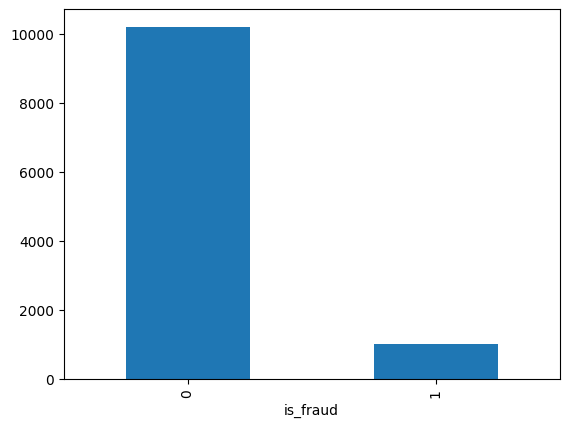

In [11]:
# Visualizing the distribution of the target variable
df['is_fraud'].value_counts().plot(kind='bar');

OBSERVATION

We Can see that dataset is highly imbalanced with small percentage of fraud cases so we need to handle class imbalance later on 

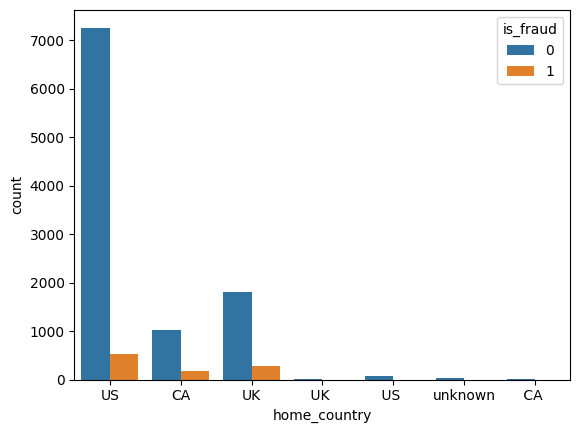

In [12]:
# visualize the distribution of the home_country column to see which country has more fraud cases
sns.countplot(x='home_country', hue='is_fraud', data=df);


USA has the highest number of fraud cases and legit cases followed by Uk. Canada has the least

Also the column is insconsistent as have many repetitions of the country so we need to handle and clean it

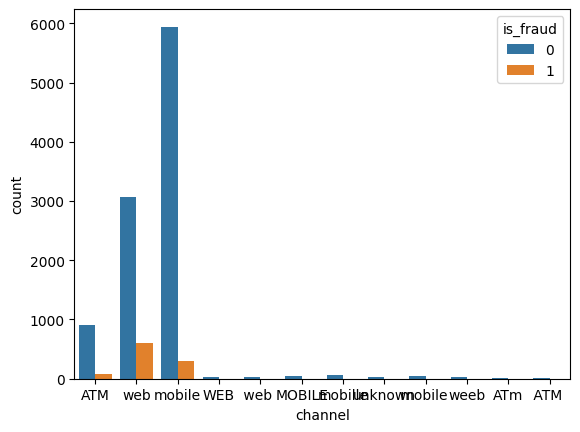

In [13]:
# visualize the distribution of the channel column to see which channel has more fraud cases
sns.countplot(x='channel', hue='is_fraud', data=df);

Web channel has the highest numbers of fraud cases followed by mobile,mobile has the highest numbers of legit transactions.ATM has the least numbers of both fraud and legit cases 

Also the entries in the channel column are inconsistent as we have so many repetitions and mispelled values we need to handle inconsistencies 

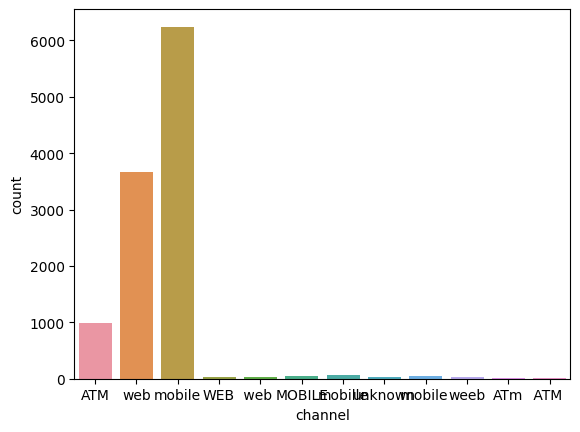

In [ ]:
# which channel is used the most for transactions
sns.countplot(x='channel', data=df)
plt.show()

Observation 

Mobile channel is used the most for transactions followed by web and Atm

In [14]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

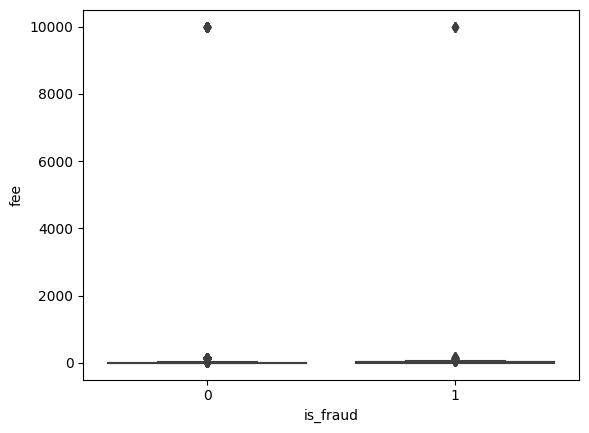

In [18]:
sns.boxplot(x='is_fraud', y='fee', data=df);

DATA CLEANING AND PRE-PROCESSING

In [15]:
# convert the amount_src column to numeric data type
df['amount_src']=pd.to_numeric(df['amount_src'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11196 non-null  float64
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  object 


amount_src column has been converted to numeric datatype

In [102]:
# Handling misssing values in the dataset
df['timestamp']=df['timestamp'].fillna(df['timestamp'].mode()[0])
df['amount_src']=df['amount_src'].fillna(df['amount_src'].mean())
df['amount_usd']=df['amount_usd'].fillna(df['amount_usd'].mean())
df['fee']=df['fee'].fillna(df['fee'].mean())
df['ip_country']=df['ip_country'].fillna(df['ip_country'].mode()[0])
df['kyc_tier']=df['kyc_tier'].fillna(df['kyc_tier'].mode()[0])
df['device_trust_score']=df['device_trust_score'].fillna(df['device_trust_score'].mean())


In [103]:
# Drop the ip_address column bcos it has too many unique values and it is not useful for our analysis
df.drop('ip_address', axis=1, inplace=True)

In [104]:
# converting the timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'],errors='coerce')

df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek


In [105]:
# converting the amount_src column to float 
df['amount_src'] = pd.to_numeric(df['amount_src'],errors='coerce')

In [106]:
# The timestamp column has been converted to datetime format and the amount_src column has 
# been converted to numeric format.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11200 non-null  object             
 1   customer_id                11200 non-null  object             
 2   timestamp                  11140 non-null  datetime64[ns, UTC]
 3   home_country               11200 non-null  object             
 4   source_currency            11200 non-null  object             
 5   dest_currency              11200 non-null  object             
 6   channel                    11200 non-null  object             
 7   amount_src                 11200 non-null  float64            
 8   amount_usd                 11200 non-null  float64            
 9   fee                        11200 non-null  float64            
 10  exchange_rate_src_to_dest  11200 non-null  float64            
 11  device_

In [107]:
df.isnull().sum()

transaction_id                0
customer_id                   0
timestamp                    60
home_country                  0
source_currency               0
dest_currency                 0
channel                       0
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                      0
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
hour                         60
day                          60
month                        60
day_of_week                  60
dtype: int64

we have missing values in the newly engineered features hour,day,month,timestamp

In [108]:
# Filling the missing values in the timestamp, hour, day, month and 
# day_of_week columns with the mode of each column
df['timestamp']=df['timestamp'].fillna(df['timestamp'].mode()[0])
df['hour']=df['hour'].fillna(df['hour'].mode()[0])
df['day']=df['day'].fillna(df['day'].mode()[0])
df['month']=df['month'].fillna(df['month'].mode()[0])
df['day_of_week']=df['day_of_week'].fillna(df['day_of_week'].mode()[0])

In [109]:

df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day                          0
month                        0
day_of_week                  0
dtype: int64

In [110]:
# Filling the missing values in the amount_src column with the mode of the column
df['amount_src']=df['amount_src'].fillna(df['amount_src'].mode()[0])
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day                          0
month                        0
day_of_week                  0
dtype: int64

In [111]:
# checking the data types of the columns again
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11200 non-null  object             
 1   customer_id                11200 non-null  object             
 2   timestamp                  11200 non-null  datetime64[ns, UTC]
 3   home_country               11200 non-null  object             
 4   source_currency            11200 non-null  object             
 5   dest_currency              11200 non-null  object             
 6   channel                    11200 non-null  object             
 7   amount_src                 11200 non-null  float64            
 8   amount_usd                 11200 non-null  float64            
 9   fee                        11200 non-null  float64            
 10  exchange_rate_src_to_dest  11200 non-null  float64            
 11  device_

In [112]:
# Dropping the timestamp column as it is no longer needed for our analysis
df.drop(['timestamp'],axis=1,inplace=True)


In [113]:
# checking the correlation between the features and the target variable
df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

is_fraud                     1.000000
txn_velocity_24h             0.752129
txn_velocity_1h              0.688922
risk_score_internal          0.603606
chargeback_history_count     0.580417
ip_risk_score                0.522118
location_mismatch            0.420506
new_device                   0.379840
corridor_risk                0.194903
exchange_rate_src_to_dest    0.152899
amount_src                   0.131126
amount_usd                   0.129801
month                        0.014410
day_of_week                  0.000391
fee                         -0.014029
day                         -0.014056
hour                        -0.085689
account_age_days            -0.285965
device_trust_score          -0.392728
Name: is_fraud, dtype: float64

In [114]:
# Dropping the transaction_id and customer_id columns as they are not useful for our
# analysis
df.drop(['transaction_id','customer_id'],axis=1,inplace=True)
df

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,...,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day,month,day_of_week
0,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,...,0,0.223,0,0,0.00,0,18.0,3.0,10.0,0.0
1,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,...,0,0.268,0,1,0.00,0,20.0,3.0,10.0,0.0
2,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,...,0,0.176,0,0,0.00,0,23.0,3.0,10.0,0.0
3,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,...,0,0.391,0,0,0.00,0,1.0,4.0,10.0,1.0
4,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,...,0,0.257,0,0,0.00,0,9.0,4.0,10.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,US,USD,CAD,mobile,271.25,271.25,5.24,1.351351,5c06f00d-a089-402b-9b14-e7bc7ae56ed2,False,...,0,0.302,1,2,0.00,0,10.0,25.0,11.0,1.0
11396,CA,CAD,NGN,web,537.17,397.51,8.86,822.222222,dafd943c-f12f-48b9-83df-401efaad0fe3,False,...,2,0.730,3,6,0.00,1,7.0,26.0,11.0,2.0
11397,CA,CAD,INR,web,205.15,151.81,4.00,61.666667,94475656-37f3-4b9c-b3cd-6d89416866ac,True,...,1,0.605,3,4,0.12,1,6.0,27.0,11.0,3.0
11398,US,USD,PHP,mobile,78.03,78.03,1.96,58.823529,0eab90ef-4273-4239-8b51-2c96b2a24756,False,...,0,0.375,0,2,0.00,0,0.0,28.0,11.0,4.0


In [115]:
# Handling the home_country column by converting it to uppercase and replacing any 
# missing values with NaN
import numpy as np

df['home_country'] = (
    df['home_country']
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(['NAN', 'UNKNOWN'], np.nan))


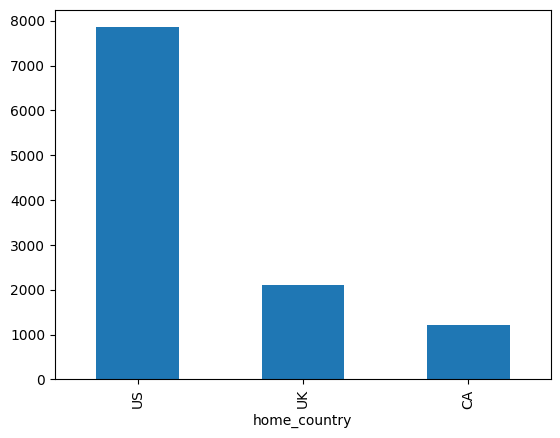

In [116]:
# Visualizing the distribution of the home_country column
df['home_country'].value_counts().plot(kind='bar');

In [117]:
# checking the unique values in the source_currency column
df['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [118]:
df.isnull().sum()

home_country                 32
source_currency               0
dest_currency                 0
channel                       0
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                      0
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
hour                          0
day                           0
month                         0
day_of_week                   0
dtype: int64

In [119]:
# checking the unique values in the dest_currency column
df['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [120]:
# checking the unique values in the channel column
# The column is inconsstent as it has different values for the same channel, for example, 'mobile' and 'Mobile' are the same channel but they are represented differently in the dataset. We will handle this inconsistency by converting all the values in the channel column to lowercase.
df['channel'].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'mobille',
       'unknown', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

In [121]:
# cleaning the channel column bcos it has some misspelled values and also has some leading and trailing spaces
df['channel'] = df['channel'].str.strip().str.lower()
mapping = {
    'weeb': 'web',
    'mobille': 'mobile'
}

df['channel'] = df['channel'].replace(mapping)
df['channel'].unique()

array(['atm', 'web', 'mobile', 'unknown'], dtype=object)

In [122]:
# checking the unique values in the new_device column
df['new_device'].unique()

array([False,  True])

In [123]:
df.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day', 'month',
       'day_of_week'],
      dtype='object')

In [124]:
# checking the unique values in the ip_country column
df['ip_country'].unique()

array(['US', 'CA', 'UK', ' US  ', 'NAN', 'unknown', ' CA  ', ' UK  ',
       ' nan  '], dtype=object)

In [125]:
# cleaning the ip_country column by converting it to uppercase and replacing any missing values with 
# NaN, then filling the missing values with the mode of the column
df['ip_country'] = (
    df['ip_country']
    .str.strip()
    .str.upper()
    .replace(['NAN', 'UNKNOWN'], np.nan)
    .fillna(df['ip_country'].mode()[0])
)

In [126]:
# checking the unique values in the location_mismatch column
df['location_mismatch'].unique()

array([False,  True])

In [127]:
#cleaning the kyc_tier column by converting it to lowercase and replacing any misspelled values with the 
# correct values, then filling the missing values with the mode of the column also replace white spaces
df['kyc_tier'] = df['kyc_tier'].str.strip().str.lower()
mapping = {
    'standrd': 'standard',
    'enhancd': 'enhanced'
}

df['kyc_tier'] = df['kyc_tier'].replace(mapping)


df['kyc_tier'] = df['kyc_tier'].replace(['nan', 'unknown'], np.nan)

df['kyc_tier'] = df['kyc_tier'].fillna(df['kyc_tier'].mode()[0])

In [128]:
# checking for missing values in the kyc_tier column after cleaning
df['kyc_tier'].isnull().sum()

0

In [129]:
# displaying the columns in the dataset
df.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day', 'month',
       'day_of_week'],
      dtype='object')

In [130]:
# Splitting the dataset into features and target variable
X=df[['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk','hour', 'day', 'month',
       'day_of_week']]
y=df['is_fraud']

In [131]:
# Splitting the dataset into training and testing sets bcos we would evaluate the 
# performance of our model on the testing set after training it on the training set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [132]:
# filling up the missing values in the home country and amount_src column
X_train['home_country']=X_train['home_country'].fillna(X_train['home_country'].mode()[0], inplace=True)
X_train['amount_src']=X_train['amount_src'].fillna(X_train['amount_src'].mean(), inplace=True)
X_test['home_country']=X_test['home_country'].fillna(X_test['home_country'].mode()[0], inplace=True)
X_test['amount_src']=X_test['amount_src'].fillna(X_test['amount_src'].mean(), inplace=True)


In [133]:
# filling up the missing values in the amount_src column
X_train['amount_src']=X_train['amount_src'].fillna(X_train['amount_src'].mean(), inplace=True)
X_test['amount_src']=X_test['amount_src'].fillna(X_test['amount_src'].mean(), inplace=True)

In [134]:
# Creating an Instance of OneHotEncoder that will convert our categorical data to numbers
# Fitting the encoder object on our training data
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)
encoder.fit(X_train[['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country',]])

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [135]:
# Transforming both train and test data
X_train_encoded = encoder.transform(X_train[['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country']])

X_test_encoded = encoder.transform(X_test[['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country']])

In [136]:
# Converting the encoded columns to DataFrame 
encoded_cols = encoder.get_feature_names_out([
    'home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country'
])

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

In [137]:
# Drop Original columns and merge the encoded columns with the Dataset
X_train = X_train.drop(['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country'], axis=1)
X_test = X_test.drop(['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country',], axis=1)

X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

In [138]:
# drop the device_id as it is not needed for our analysis
X_train.drop(['device_id'], axis=1, inplace=True)
X_test.drop(['device_id'], axis=1, inplace=True)

In [139]:
#creating an object of label encoder,fitting it on training data and transforming it on test data
# We want to convert location mismatch column to numbers
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
X_train['location_mismatch']=labelencoder.fit_transform(X_train['location_mismatch'])
X_test['location_mismatch']=labelencoder.transform(X_test['location_mismatch'])

In [140]:
# fitting it label encoder on training data and transforming it on test data
# We want to convert new device column to numbers
X_train['new_device']=labelencoder.fit_transform(X_train['new_device'])
X_test['new_device']=labelencoder.transform(X_test['new_device'])

In [141]:
# We want to convert our kyc_tier column to numbers with Ordinal encoder 
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
X_train['kyc_tier'] = ordinal_encoder.fit_transform(X_train[['kyc_tier']])
X_test['kyc_tier'] = ordinal_encoder.transform(X_test[['kyc_tier']])

In [142]:
X_train.drop('amount_src',axis=1,inplace=True)
X_test.drop('amount_src',axis=1,inplace=True)

In [143]:
# importing smote
# we want to create synthetic data for our minority class legit transactions category 
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [144]:
# Checking class balance .After SMOTE, our classes will be equal
print(y_train.value_counts())
print(y_train_resampled.value_counts())

is_fraud
0    8161
1     799
Name: count, dtype: int64
is_fraud
0    8161
1    8161
Name: count, dtype: int64


In [ ]:
# This code is importing StandardScaler object that will transform our input data into same range 
#so that our model can learn better and also it will help to improve the performance of our model
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled,y_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [146]:
# importing Logistic Regression model and fitting it on our training data
from sklearn.linear_model import LogisticRegression
logsitic_model = LogisticRegression(random_state=42,class_weight='balanced')
lr_model=logsitic_model.fit(X_train_resampled, y_train_resampled)

In [147]:
# Evaluating the model performance on the test set
logsitic_model.score(X_test_scaled, y_test)*100

95.49107142857143

Observation
The model achieved 95% accuracy on the test data meaning we have a balanced model.The model performed well on the training data and test data. So we have a generalized model.

In [148]:
# Evaluating the model performance with classification report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, lr_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2044
           1       0.69      0.82      0.75       196

    accuracy                           0.95      2240
   macro avg       0.84      0.89      0.86      2240
weighted avg       0.96      0.95      0.95      2240



Observation
We have a generalized model our model was able to recognised both the fraud transactions and legit transactions with high precision and recall